## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [2]:
data = pd.read_csv('/content/Telecom_Customer_Churn.csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.shape

(7043, 21)

In [5]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Transformation

In [7]:
# Dropping unnecessary columns (if applicable)
data.set_index('customerID', inplace=True)

# Converting 'TotalCharges' to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0).astype(int)

In [8]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151,Yes


## Label Encoding

In [9]:
#transfomartion categorical to numerical
from sklearn.preprocessing import LabelEncoder

encode = data[['gender', 'Partner', 'Dependents',
         'PhoneService', 'MultipleLines', 'InternetService',
         'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'Churn']]

le = LabelEncoder()

for column in encode:
  data[column] = le.fit_transform(data[column])

In [10]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


## Correlation Plot

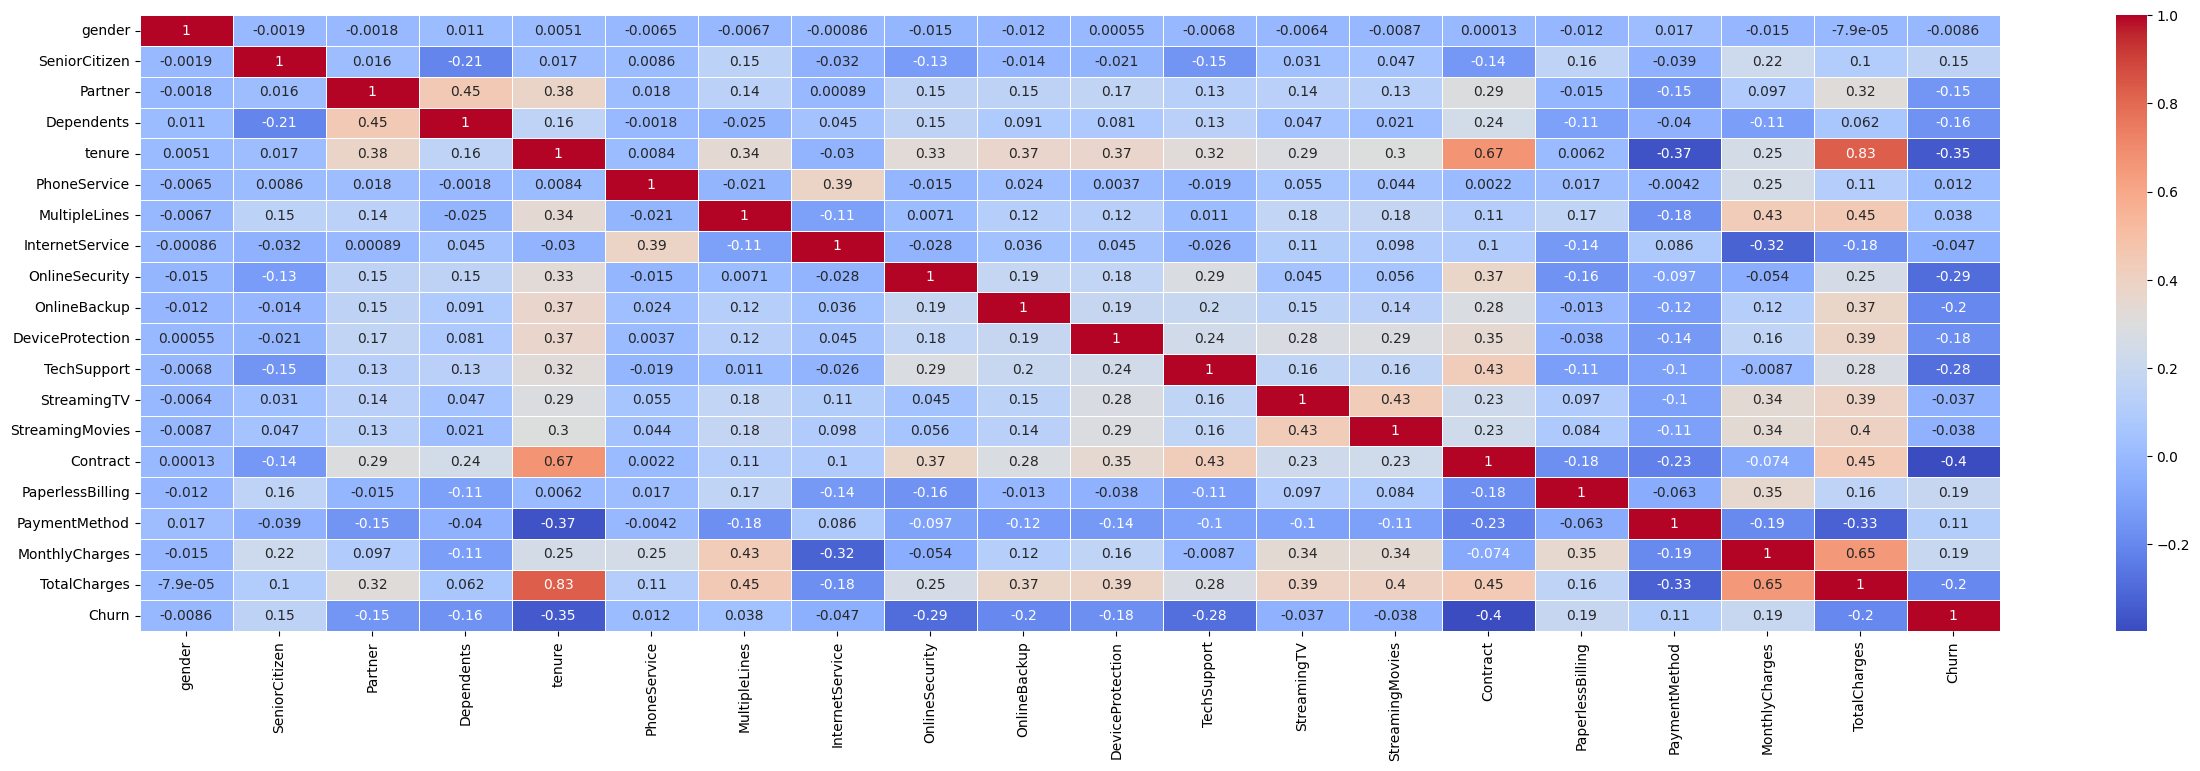

In [11]:
plt.figure(figsize=(30, 8))
sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap='coolwarm')
plt.show()

## Observations
The heatmap shows relationships between features and their impact on **Churn**.

- Tenure & TotalCharges are highly correlated; long-term customers pay more overall.
- Contract & Tenure show strong correlation; long-term contracts reduce churn.
- MonthlyCharges & TotalCharges are strongly related; higher bills increase total cost.

- Churn decreases with:
  - Longer tenure
  - Long-term contracts
  - Services like OnlineSecurity and TechSupport

- Churn increases with:
  - Higher MonthlyCharges
  - PaperlessBilling
  - SeniorCitizen status (slightly)

- Gender has almost no effect on churn.

## Build Model

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
X = data.drop('Churn', axis=1)
y = data['Churn']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# train random forest model
rf = RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42,)
rf.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=42)

## Random Forest Model Evaluation

In [16]:
# Predict on training and testing data
train_preds = rf.predict(x_train)
test_preds = rf.predict(x_test)

In [17]:
# Calculate accuracy
train_accuracy_rf = accuracy_score(y_train, train_preds)
test_accuracy_rf = accuracy_score(y_test, test_preds)

In [18]:
print(f"Training Accuracy: {train_accuracy_rf:.4f}")
print(f"Testing Accuracy: {test_accuracy_rf:.4f}")

Training Accuracy: 0.9984
Testing Accuracy: 0.7970


In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Select the first tree in the forest
single_tree = rf.estimators_[0]


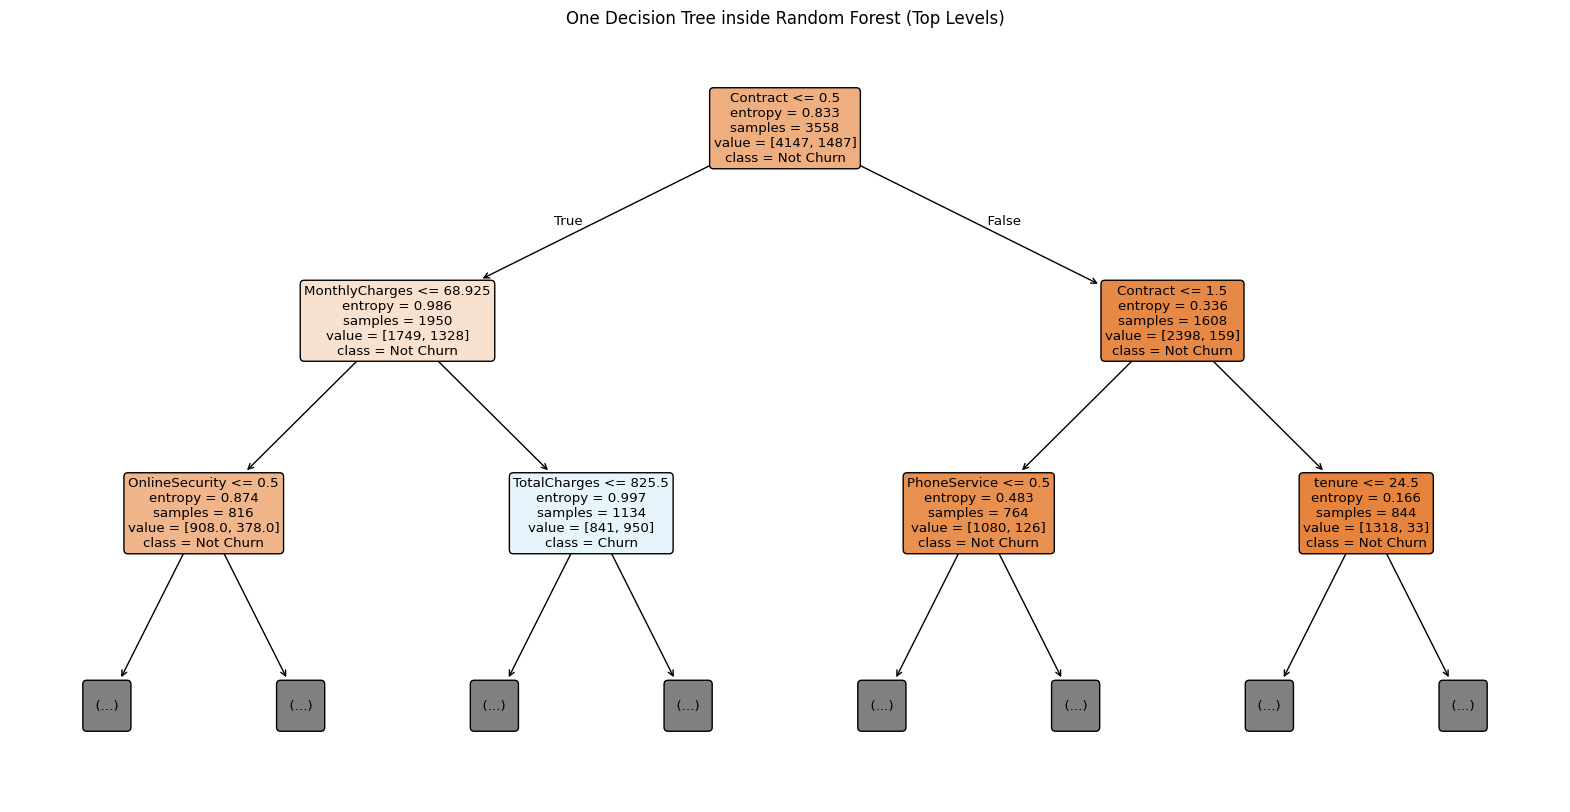

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(
    single_tree,
    feature_names=X.columns,
    class_names=["Not Churn", "Churn"],
    max_depth=2,          # limit depth
    filled=True,
    rounded=True
)
plt.title("One Decision Tree inside Random Forest (Top Levels)")
plt.show()


## Confusion Matrix

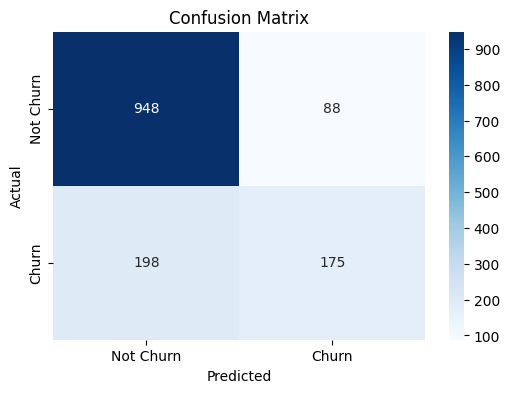

In [21]:
# Compute confusion matrix
cm = confusion_matrix(y_test, test_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not Churn", "Churn"], yticklabels=["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- True Negative (`TN`): Correctly predicted negative class (Actual = `Not Churn`, Predicted = `Not Churn`)
- False Positive (`FP`): Incorrectly predicted as positive (Actual = `Not Churn`, Predicted = `Churn`)
- False Negative (`FN`): Incorrectly predicted as negative (Actual = `Churn`, Predicted = `Not Churn`)
- True Positive (`TP`): Correctly predicted positive class (Actual = `Churn`, Predicted = `Churn`)

## Classification Report

In [22]:
# classification report
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_preds))

Classification Report (Testing Data):

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



##AUC-ROC Curve

In [23]:
y_prob = rf.predict_proba(x_test)[:, 1]
y_prob

array([0.75, 0.13, 0.  , ..., 0.01, 0.03, 0.51])

In [24]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [27]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_prob)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='AUC ROC Curve',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


- The above plot Shows the ROC curve, plotting True Positive Rate vs False Positive Rate

- AUC = 0.84, indicating good class separation

- Red points represent different decision thresholds

- Dashed diagonal is the random classifier baseline

- Curve closer to the top-left means better model performance





##PR Curve

In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import plotly.graph_objects as go
import numpy as np

# Compute precision, recall, thresholds
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

# Average Precision (PR-AUC)
pr_auc = average_precision_score(y_test, y_prob)

# PR curve
trace0 = go.Scatter(
    x=recall,
    y=precision,
    mode='lines',
    name=f'PR curve (AP = {pr_auc:.2f})'
)

# Mark some threshold points (avoid clutter)
n = 10
indices = np.arange(len(pr_thresholds)) % n == 0

trace1 = go.Scatter(
    x=recall[:-1][indices],   # precision_recall_curve gives 1 extra precision value
    y=precision[:-1][indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={t:.2f}" for t in pr_thresholds[indices]],
    textposition='top center'
)

# Baseline = fraction of positives (churn rate)
baseline = y_test.mean()

trace2 = go.Scatter(
    x=[0, 1],
    y=[baseline, baseline],
    mode='lines',
    name='Random baseline',
    line=dict(dash='dash')
)

# Layout
layout = go.Layout(
    title='Precision–Recall Curve',
    xaxis=dict(title='Recall'),
    yaxis=dict(title='Precision'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

fig_pr = go.Figure(data=[trace0, trace1, trace2], layout=layout)

# Show PR curve
fig_pr.show()


The Precision–Recall curve shows the trade-off between precision and recall at different classification thresholds.

- X-axis (Recall): how many actual positives are correctly found

- Y-axis (Precision): how many predicted positives are actually correct

- As recall increases, precision usually decreases (more false positives).

- The AP = 0.65 indicates the model performs better than random guessing.

- The dashed line is the random baseline, so the curve above it means the model is useful.

For imbalanced datasets, the PR curve is a better evaluation metric than ROC because it focuses on the positive class.
ROC–AUC is still useful but can be overly optimistic when classes are highly imbalanced.

## Symmary:
1. **Overall Accuracy**:
  - The Random Forest model achieved an overall accuracy of 79%, meaning it correctly classified 79% of the samples in the test data.

2. **Class-Specific Performance:**

**Class 0 (Non-Churn):**

- `Precision`: 83% - When the model predicts a customer will not churn, it is correct 83% of the time.
- `Recall`: 92% - The model correctly identifies 92% of the actual non-churn customers.
- `F1-Score`: 87% - The balance between precision and recall is high for this class.

**Class 1 (Churn):**
- `Precision`: 67% - When the model predicts a customer will churn, it is correct 67% of the time.
- `Recall`: 47% - The model identifies only 47% of the actual churn cases.
- `F1-Score`: 55% - The performance on this class is relatively weaker compared to Class 0.

3. **Model Weakness:**
- The model struggles to correctly identify churners (Class 1) with a low recall of 47%. This means many churn cases are being missed, which is critical in customer churn analysis.


## Improvements:
**Feature Engineering:**

- Investigate if additional features can help distinguish churners more effectively.
- Perform `feature importance analysis` to identify and focus on the most informative features.

**Hyperparameter Tuning:**

- Adjust Random Forest parameters like `max_depth`, `min_samples_split`, and `class_weight` to improve the model's recall for churn cases.

**Consider Alternative Models:**

- Explore boosting methods (e.g., Gradient Boosting, XGBoost) as they often perform better on imbalanced datasets.

